# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_239/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_239/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


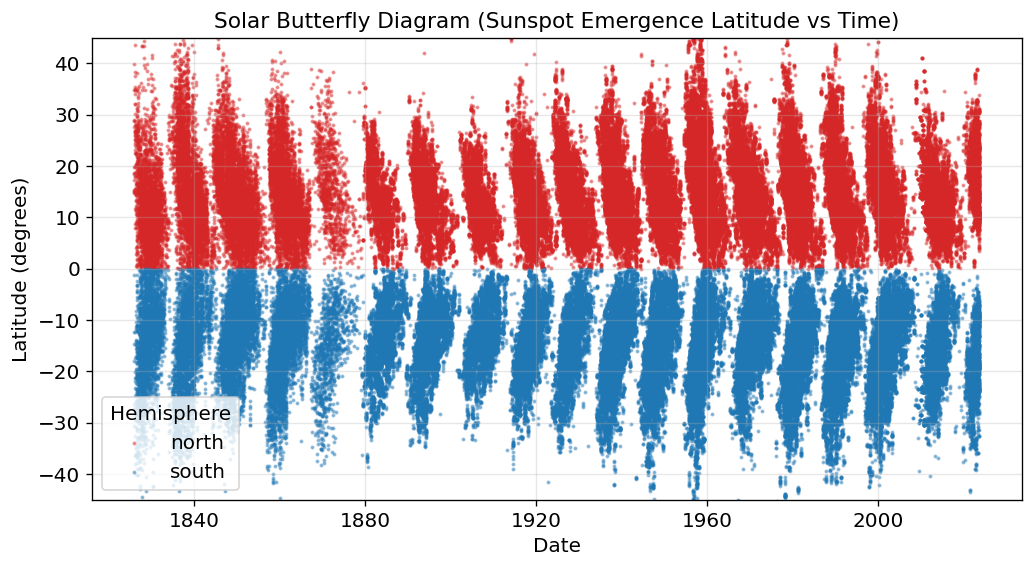

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


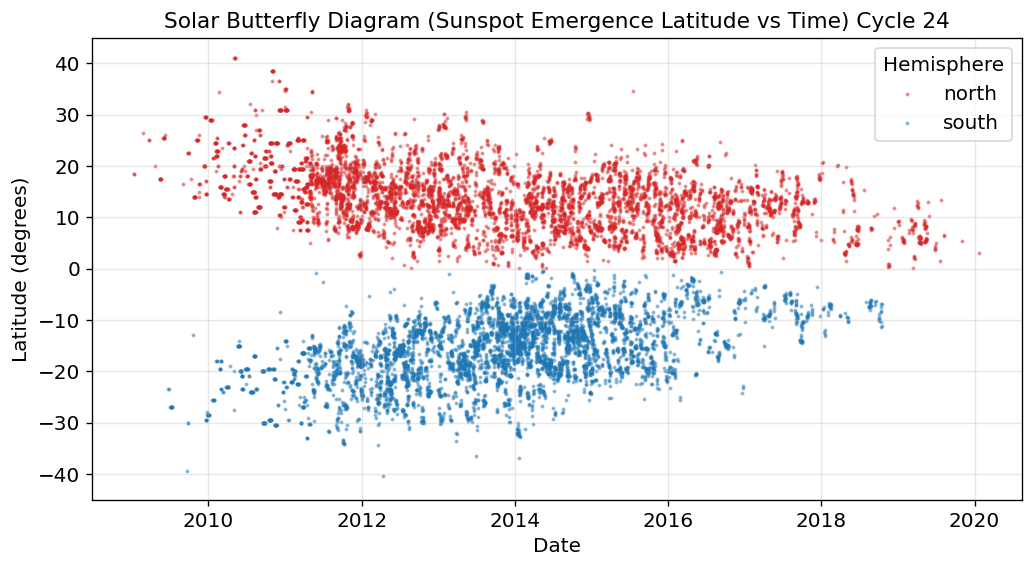

In [5]:
# Your code here: Visualize a single solar cycle
df_cycle = df[df["CYCLE"] == 24].copy()

df_cycle["hemisphere"] = df_cycle["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time) Cycle 24")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()



## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


In [6]:
df_mean_lat = df.set_index('date').groupby('hemisphere').resample('M')['latitude'].mean().reset_index()
df_mean_lat.rename(columns={'date': 'month'}, inplace=True)



/tmp/ipykernel_239/1634686721.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mean_lat = df.set_index('date').groupby('hemisphere').resample('M')['latitude'].mean().reset_index()


,hemisphere,month,latitude
0,north,1825-11-30,27.091429
1,north,1825-12-31,24.452105
2,north,1826-01-31,25.339167
3,north,1826-02-28,24.231667
4,north,1826-03-31,15.315000


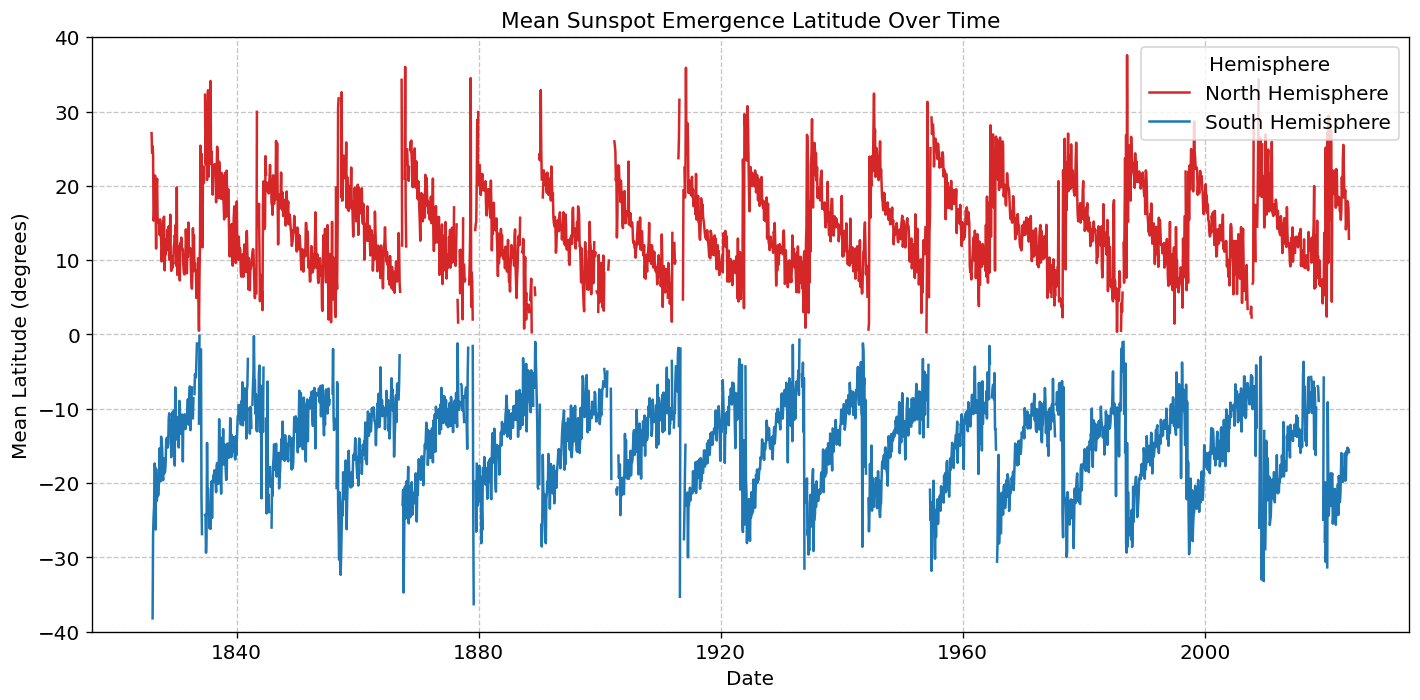

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors for hemispheres
colors = {"north": "tab:red", "south": "tab:blue"}

# Plot mean latitude for each hemisphere
for hemi, group in df_mean_lat.groupby("hemisphere"):
    ax.plot(group["month"], group["latitude"], color=colors[hemi], label=f'{hemi.capitalize()} Hemisphere')

ax.set_title("Mean Sunspot Emergence Latitude Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_ylim(-40, 40)
plt.tight_layout()
plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*

## AI Response
The most effective way to use an AI to learn complex, technical subjects is to prompt it for **active learning** rather than passive reading. Simply asking an AI to summarize a topic creates an "illusion of competence"—you feel like you understand it, but you won't retain it (Brown, Roediger, & McDaniel, *Make It Stick*, 2014).

Here are the three best prompting frameworks to use, grounded in cognitive science:

### 1. The Feynman Technique (For Conceptual Foundation)
* **The Science:** Translating complex jargon into simple terms and analogies exposes gaps in your fundamental understanding (a method attributed to physicist Richard Feynman).
* **The Prompt:** *"Explain [concept] as if I am a high school student. Use a concrete, real-world analogy. Once I understand the analogy, gradually add the actual technical terminology back in."*
* **When to use it:** When starting a new topic, like understanding **magnetic reconnection** in solar flares or the basic intuition behind **gradient descent** in machine learning.

### 2. Socratic Questioning (For Deep Comprehension)
* **The Science:** Guided discovery forces you to construct your own mental models, which improves long-term retention compared to explicit instruction (Constructivist Learning Theory).
* **The Prompt:** *"I am trying to learn about [concept]. Do not just give me the answer. Instead, act as a Socratic tutor. Ask me a series of probing questions, one at a time, to help me deduce the mechanics on my own. Wait for my answer before moving on."*
* **When to use it:** When you need to understand *how* a system works, such as how **backpropagation** updates weights in a neural network, or how the **solar dynamo** generates magnetic fields.

### 3. Active Recall & Scaffolding (For Retention)
* **The Science:** Actively retrieving information from memory (the "Testing Effect") strengthens neural pathways far more efficiently than re-reading notes (Roediger & Karpicke, 2006).
* **The Prompt:** *"Quiz me on [topic]. Ask one question at a time. If I get it wrong, do not give me the exact answer—give me a hint to help me figure it out. If I get it right, make the next question slightly harder."*
* **When to use it:** When testing your working knowledge of **Convolutional Neural Network (CNN)** architectures or the different layers and temperature gradients of the **solar atmosphere**.

By forcing the AI to act as a conversational tutor and tester, you shift the cognitive load back onto yourself, which is where actual learning happens.

## Reflection
Alot of this advice I feel like I already utilize quite a bit, but I will continue to prompt the assistance to explain the problem more so than solve it for me, and I also prefer to use it as more of a documentation researcher
